# Cloud Masking Sentinel-2 L2A from Microsoft Planetary Computer

This notebook shows how to query a Sentinel-2 L2A scene from the [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a) and generate a cloud mask using OmniCloudMask.

**Extra dependencies:**
```
pip install pystac-client planetary-computer
```

In [1]:
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import planetary_computer
import pystac_client
import rasterio
from rasterio.enums import Resampling

from omnicloudmask import predict_from_array

## 1. Fetch a specific Sentinel-2 L2A scene from Planetary Computer

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

ITEM_ID = "S2C_MSIL2A_20260104T015411_R117_T51KYB_20260104T055910"
item = catalog.get_collection("sentinel-2-l2a").get_item(ITEM_ID)
print(f"Found: {item.id}  (cloud cover: {item.properties['eo:cloud_cover']}%)")

Found: S2C_MSIL2A_20260104T015411_R117_T51KYB_20260104T055910  (cloud cover: 8.583386%)


## 2. Load all bands at 20 m in parallel

OmniCloudMask expects a `(3, H, W)` array in **Red, Green, NIR** order.
We also download Blue (B02) for true-colour visualisation. All four bands are
fetched concurrently at 20 m — B02/B03/B04 are downsampled from their native
10 m, B8A is read at its native resolution.

> **Note:** OmniCloudMask is robust to a wide range of spatial resolutions, so
> running at 20 m instead of 10 m halves the number of pixels and gives faster
> inference with negligible impact on mask quality.

In [3]:
def read_band(href: str, resolution: float = 20.0) -> np.ndarray:
    with rasterio.open(href) as src:
        scale = src.res[0] / resolution
        out_shape = (int(src.height * scale), int(src.width * scale))
        return src.read(1, out_shape=out_shape, resampling=Resampling.bilinear)


bands = ["B04", "B03", "B02", "B8A"]
with ThreadPoolExecutor() as executor:
    red, green, blue, nir = executor.map(
        read_band, [item.assets[b].href for b in bands]
    )

scene = np.stack([red, green, nir])  # shape: (3, H, W) for OmniCloudMask
print(f"Scene shape: {scene.shape}")

Scene shape: (3, 5490, 5490)


## 3. Run OmniCloudMask

In [4]:
mask = predict_from_array(input_array=scene)
print(f"Mask shape: {mask.shape}")
print(f"Classes — 0: clear, 1: thick cloud, 2: thin cloud, 3: cloud shadow")

Mask shape: (1, 5490, 5490)
Classes — 0: clear, 1: thick cloud, 2: thin cloud, 3: cloud shadow


## 4. Visualise

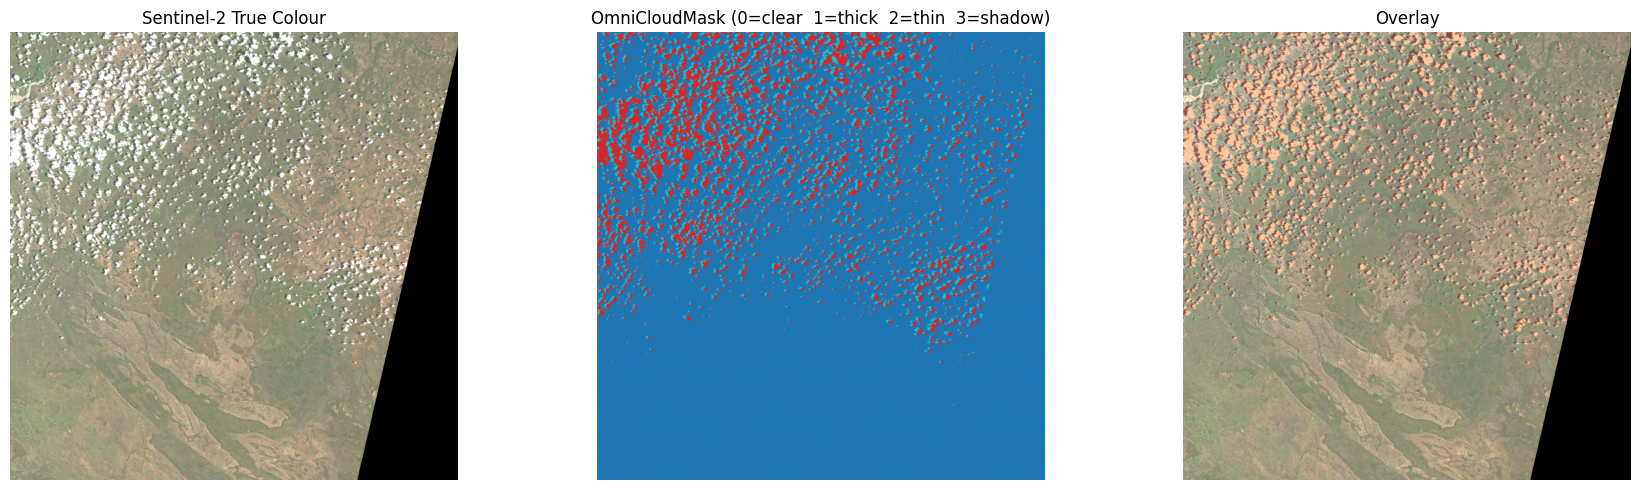

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rgb = np.stack([red, green, blue])
rgb = np.clip(rgb / 3000, 0, 1).transpose(1, 2, 0)

# Panel 1: true colour
axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 True Colour")
axes[0].axis("off")

# Panel 2: cloud mask
axes[1].imshow(mask.squeeze(), cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

# Panel 3: overlay — clear pixels transparent, others at 40% opacity
tab10 = plt.get_cmap("tab10")
mask_sq = mask.squeeze()
rgba = np.zeros((*mask_sq.shape, 4), dtype=float)
for cls in range(4):
    colour = tab10(cls / 9)
    where = mask_sq == cls
    rgba[where, :3] = colour[:3]
    rgba[where, 3] = 0.0 if cls == 0 else 0.4

axes[2].imshow(rgb)
axes[2].imshow(rgba)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

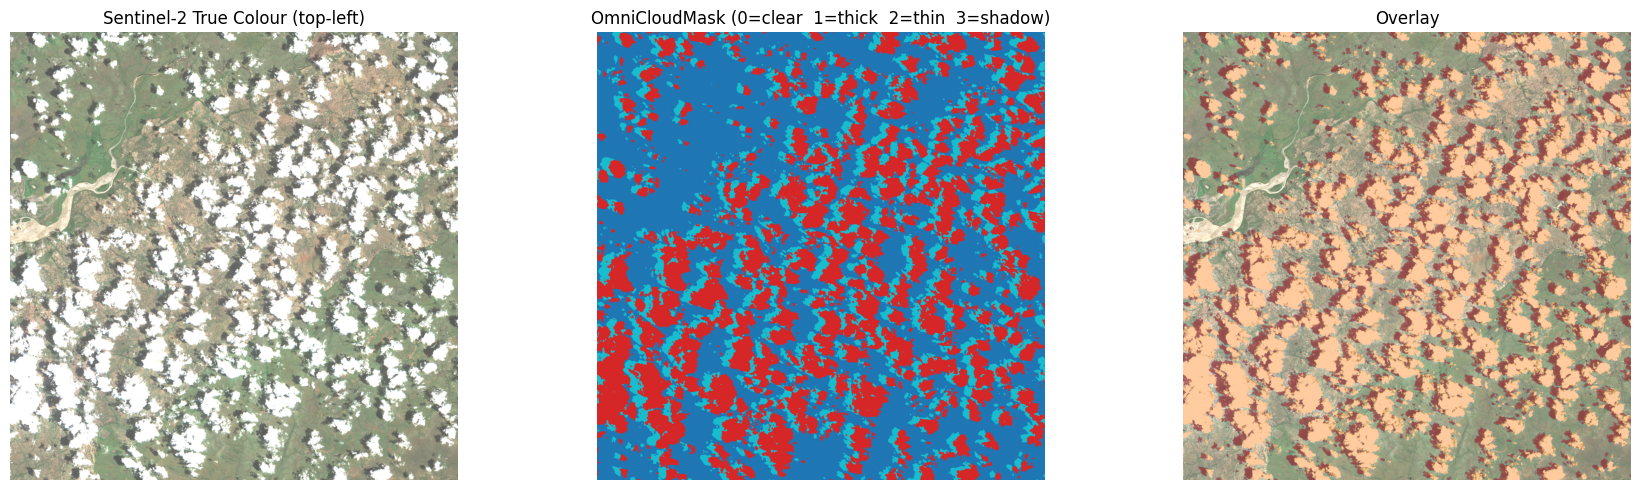

In [ ]:
# Zoom into the top-left
h, w = mask_sq.shape
rs, re, cs, ce = 0, h // 3, 0, w // 3

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(rgb[rs:re, cs:ce])
axes[0].set_title("Sentinel-2 True Colour (top-left)")
axes[0].axis("off")

axes[1].imshow(mask_sq[rs:re, cs:ce], cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

axes[2].imshow(rgb[rs:re, cs:ce])
axes[2].imshow(rgba[rs:re, cs:ce])
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()